In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
dir = r"try_05"

x_train = pd.read_pickle(os.path.join(dir , "x_train.pkl"))
x_test = pd.read_pickle(os.path.join(dir , "x_test.pkl"))

y_train = pd.read_pickle(os.path.join(dir , "y_train.pkl"))
y_test = pd.read_pickle(os.path.join(dir , "y_test.pkl"))

rf1 = joblib.load(os.path.join(dir , "model_default.pkl"))
rf2 = joblib.load(os.path.join(dir , "model_maxdepth35.pkl"))

In [3]:
models = {
    "RF_Default": rf1,
    "RF_MaxDepth": rf2
}

In [4]:
def compute_pr_curve(model, x_test, y_test):
    y_prob = model.predict_proba(x_test)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    return y_prob, precision, recall, thresholds, pr_auc

In [5]:
def find_best_threshold(precision, recall, thresholds):
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    print("Best Threshold:", best_threshold)
    print("Best F1:", f1_scores[best_idx])
    
    return best_threshold, f1_scores

In [6]:
def plot_pr_curve(models_dict, x_test, y_test):
    plt.figure()
    
    for name, model in models_dict.items():
        y_prob = model.predict_proba(x_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        
        plt.plot(recall, precision, label=name)
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Comparison")
    plt.legend()
    plt.show()

In [7]:
def evaluate_thresholds(y_prob, y_test, thresholds_list=[0.1 , 0.2 , 0.3 , 0.4 , 0.5]):
    
    for t in thresholds_list:
        print(f"\n===== Threshold: {t} =====")
        
        y_pred = (y_prob >= t).astype(int)
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

In [8]:
def final_evaluation(y_prob, y_test, threshold):
    
    print("\n===== FINAL MODEL EVALUATION =====")
    print("\nBest Threshold:", threshold)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    print("\n--- Overall Metrics ---")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("PR-AUC   :", average_precision_score(y_test, y_prob))
    
    print("\n--- Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))
    
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

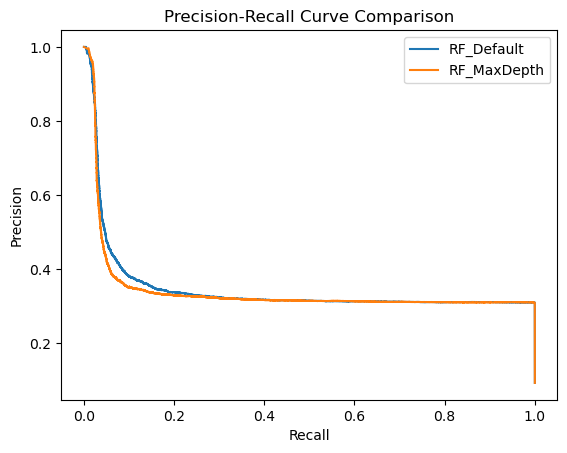

In [9]:
plot_pr_curve(models, x_test, y_test)

In [10]:
y_prob1, precision1, recall1, thresholds1, pr_auc1 = compute_pr_curve(rf1, x_test, y_test)
best_threshold1, _ = find_best_threshold(precision1, recall1, thresholds1)
print("\n")
y_prob2, precision2, recall2, thresholds2, pr_auc2 = compute_pr_curve(rf2, x_test, y_test)
best_threshold2, _ = find_best_threshold(precision2, recall2, thresholds2)

Best Threshold: 0.7022132920141462
Best F1: 0.4725766242522828


Best Threshold: 0.16061581809340356
Best F1: 0.4725899165243635


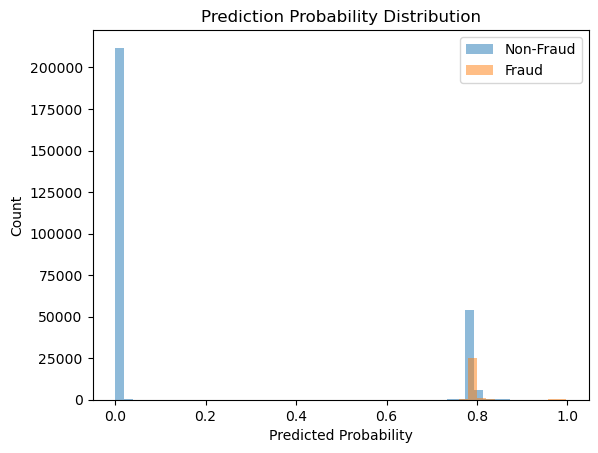

In [11]:
plt.figure()
plt.hist(y_prob1[y_test == 0], bins=50, alpha=0.5, label="Non-Fraud")
plt.hist(y_prob1[y_test == 1], bins=50, alpha=0.5, label="Fraud")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

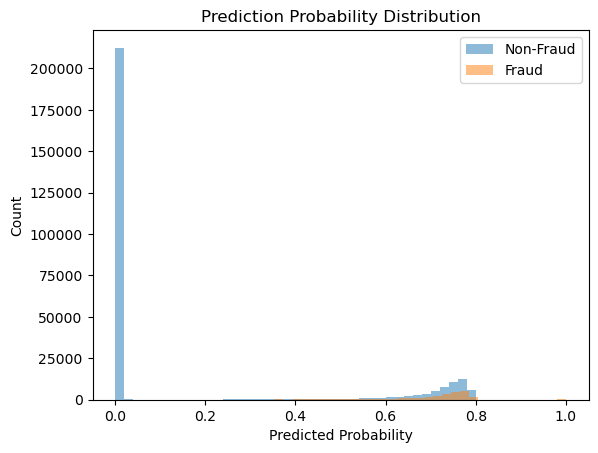

In [12]:
plt.figure()
plt.hist(y_prob2[y_test == 0], bins=50, alpha=0.5, label="Non-Fraud")
plt.hist(y_prob2[y_test == 1], bins=50, alpha=0.5, label="Fraud")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

In [13]:
# evaluate_thresholds(y_prob1, y_test)

In [14]:
# evaluate_thresholds(y_prob2, y_test)

In [15]:
# from sklearn.model_selection import StratifiedKFold, cross_validate
# from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# # Define Stratified K-Fold (3 folds is enough for 1.7M rows to save time)
# skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# scoring = {
#     'f1': 'f1',
#     'recall': 'recall',
#     'precision': 'precision'
# }

# # Setting return_train_score=True is what allows us to check for overfitting
# results = cross_validate(
#     rf1, x_train, y_train, 
#     cv=skf, 
#     scoring=scoring, 
#     return_train_score=True
# )

# print(f"Average Training F1: {np.mean(results['train_f1']):.4f}")
# print(f"Average Validation F1: {np.mean(results['test_f1']):.4f}")
# print(f"---")
# print(f"The 'Overfit Gap': {np.mean(results['train_f1']) - np.mean(results['test_f1']):.4f}")

In [16]:
final_evaluation(y_prob1, y_test, best_threshold1)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.7022132920141462

--- Overall Metrics ---
Accuracy : 0.7945739759385992
Precision: 0.3095560488346282
Recall   : 0.9983177034862911
F1 Score : 0.4725766278656026
PR-AUC   : 0.34749895853047447

--- Confusion Matrix ---
[[212911  62209]
 [    47  27891]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.77      0.87    275120
           1       0.31      1.00      0.47     27938

    accuracy                           0.79    303058
   macro avg       0.65      0.89      0.67    303058
weighted avg       0.94      0.79      0.84    303058



In [17]:
final_evaluation(y_prob2, y_test, best_threshold2)


===== FINAL MODEL EVALUATION =====

Best Threshold: 0.16061581809340356

--- Overall Metrics ---
Accuracy : 0.7945112816688554
Precision: 0.3095330545047094
Recall   : 0.9986756389147398
F1 Score : 0.47258992013685985
PR-AUC   : 0.3415924380115183

--- Confusion Matrix ---
[[212882  62238]
 [    37  27901]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.77      0.87    275120
           1       0.31      1.00      0.47     27938

    accuracy                           0.79    303058
   macro avg       0.65      0.89      0.67    303058
weighted avg       0.94      0.79      0.84    303058



In [18]:
feature_importance = pd.DataFrame({
    "features": x_train.columns,
    "importance": rf1.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(32)

,features,importance
8,transactionType_TRANSFER,0.288191
28,RECIP_RISK_24,0.161636
0,amount,0.112883
26,RECIP_RISK_12,0.075694
24,RECIP_RISK_6,0.068017
7,transactionType_PAYMENT,0.037684
6,transactionType_DEPOSIT,0.030087
11,balance_increase_ratio,0.028637
16,INIT_AMOUNT_DEV_TX_6,0.023545
10,amount_balance_ratio,0.023342


In [19]:
feature_importance = pd.DataFrame({
    "features": x_train.columns,
    "importance": rf2.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(32)

,features,importance
8,transactionType_TRANSFER,0.250935
28,RECIP_RISK_24,0.148590
0,amount,0.093392
26,RECIP_RISK_12,0.077859
24,RECIP_RISK_6,0.062406
7,transactionType_PAYMENT,0.034870
6,transactionType_DEPOSIT,0.032838
11,balance_increase_ratio,0.030585
16,INIT_AMOUNT_DEV_TX_6,0.029077
10,amount_balance_ratio,0.027470
